In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


=== Starting Machine Learning Pipeline ===

=== Dataset Preview ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

=== Dataset Shape ===
Total no. of rows: 768
Total no. of columns: 9

=== Target Distribution ===
count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000

/tmp/ipykernel_14763/3204661070.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


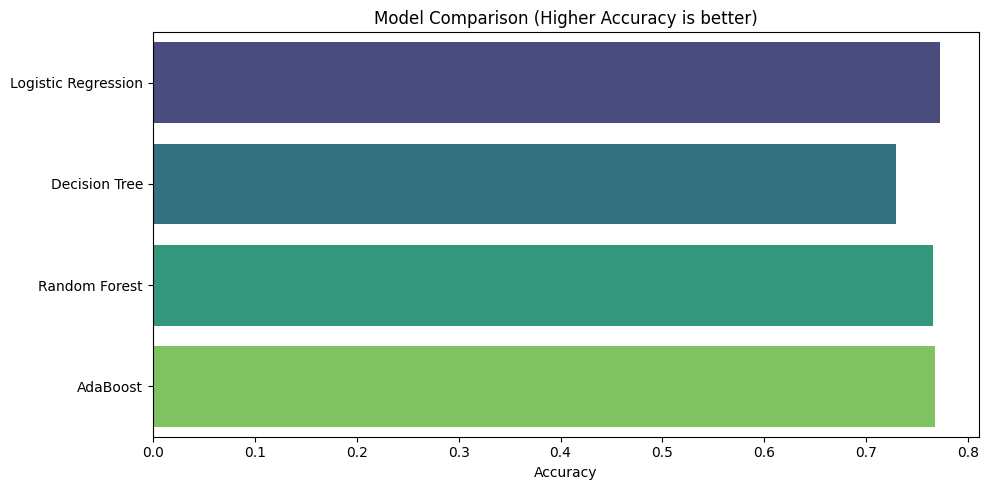


=== Final Report ===
Problem Type: classification
Best Model: Logistic Regression (Accuracy: 77.22%)


In [3]:
import pandas as pd
import numpy as np
from sklearn import (
    linear_model, tree, ensemble,
    model_selection, metrics
)
import matplotlib.pyplot as plt
import seaborn as sns

class MLlearn:
    def __init__(self, dataset, target_column=None):
        """Initialize ML pipeline with dataset and target column."""
        self.dataset = pd.read_csv(dataset)
        self.target_column = target_column
        self.problem_type = None
        self.models = {}
        self.results = {}
        self.X = None
        self.y = None

    def preprocess_data(self):
        """Perform basic data exploration and cleaning."""
        print("\n=== Dataset Preview ===")
        print(self.dataset.head())
        
        rows, columns = self.dataset.shape
        print(f"\n=== Dataset Shape ===")
        print(f"Total no. of rows: {rows}")
        print(f"Total no. of columns: {columns}")
        
        # Handle missing values
        missing_rows = self.dataset.isnull().any(axis=1).sum()
        if missing_rows > 0:
            print(f"\n=== Missing Values ===")
            print(f"Rows with missing values: {missing_rows}")
            # Fill numerical columns with median, categorical with mode
            for col in self.dataset.columns:
                if self.dataset[col].dtype == 'object':
                    self.dataset[col] = self.dataset[col].fillna(self.dataset[col].mode()[0])
                else:
                    self.dataset[col] = self.dataset[col].fillna(self.dataset[col].median())
        
        # Separate features and target
        if self.target_column:
            self.X = self.dataset.drop(columns=[self.target_column])
            self.y = self.dataset[self.target_column]
        
        print("\n=== Target Distribution ===")
        if self.target_column:
            print(self.y.describe() if self.y.dtype != 'object' else self.y.value_counts())

    def detect_problem_type(self):
        """Determine if problem is classification or regression."""
        if not self.target_column:
            return None
            
        unique_values = len(self.y.unique())
        dtype = self.y.dtype
        
        if (dtype == 'object') or (2 <= unique_values <= 20):
            self.problem_type = 'classification'
            if unique_values == 2:
                print("\nProblem type: Binary Classification")
            else:
                print(f"\nProblem type: Multiclass Classification ({unique_values} classes)")
        elif np.issubdtype(dtype, np.number):
            self.problem_type = 'regression'
            print("\nProblem type: Regression")
        else:
            self.problem_type = None
            print("\nCould not determine problem type.")
        
        return self.problem_type

    def analyze_data(self):
        """Perform basic statistical analysis."""
        print("\n=== Statistical Summary ===")
        print(self.dataset.describe())
        
        if self.target_column:
            print("\n=== Correlation with Target ===")
            numeric_cols = self.dataset.select_dtypes(include=[np.number]).columns
            print(self.dataset[numeric_cols].corr()[self.target_column].sort_values(ascending=False))

    def train_models(self):
        """Train and evaluate multiple models using cross-validation."""
        if not self.target_column:
            print("No target column specified for supervised learning.")
            return None
            
        if self.X is None or len(self.X) == 0:
            print("No samples available for training after preprocessing!")
            return None
            
        self.detect_problem_type()
        model_results = {}
        
        if self.problem_type == 'regression':
            models = {
                'Linear Regression': linear_model.LinearRegression(),
                'Decision Tree': tree.DecisionTreeRegressor(max_depth=3),
                'Random Forest': ensemble.RandomForestRegressor(n_estimators=100),
                'AdaBoost': ensemble.AdaBoostRegressor()
            }
            scoring = 'neg_mean_squared_error'
        else:  # classification
            models = {
                'Logistic Regression': linear_model.LogisticRegression(max_iter=1000),
                'Decision Tree': tree.DecisionTreeClassifier(max_depth=3),
                'Random Forest': ensemble.RandomForestClassifier(n_estimators=100),
                'AdaBoost': ensemble.AdaBoostClassifier()
            }
            scoring = 'accuracy'
        
        print(f"\n=== Training {self.problem_type.capitalize()} Models ===")
        for name, model in models.items():
            try:
                scores = model_selection.cross_val_score(
                    model, self.X, self.y, cv=min(5, len(self.X)), scoring=scoring
                )
                if self.problem_type == 'regression':
                    # Convert negative MSE to positive RMSE
                    rmse_scores = np.sqrt(-scores)
                    mean_score = rmse_scores.mean()
                    print(f"{name}: Average RMSE = {mean_score:.2f}")
                else:
                    mean_score = scores.mean()
                    print(f"{name}: Average Accuracy = {mean_score:.2%}")
                
                model_results[name] = mean_score
                self.models[name] = model
            except Exception as e:
                print(f"Error with {name}: {str(e)}")
                continue
        
        self.results = model_results
        return model_results

    def evaluate_results(self):
        """Display model evaluation results."""
        if not self.results:
            print("No results to evaluate. Run train_models() first.")
            return
            
        print("\n=== Model Evaluation Summary ===")
        for model, score in self.results.items():
            if self.problem_type == 'regression':
                print(f"{model}: RMSE = {score:.2f}")
            else:
                print(f"{model}: Accuracy = {score:.2%}")

    def visualize_results(self):
        """Create visualizations of results."""
        if not self.results:
            print("No results to visualize. Run train_models() first.")
            return
            
        print("\nGenerating visualizations...")
        
        # Model performance comparison
        plt.figure(figsize=(10, 5))
        if self.problem_type == 'regression':
            plt.title("Model Comparison (Lower RMSE is better)")
            sns.barplot(
                x=list(self.results.values()),
                y=list(self.results.keys()),
                palette='viridis'
            )
            plt.xlabel("Root Mean Squared Error (RMSE)")
        else:
            plt.title("Model Comparison (Higher Accuracy is better)")
            sns.barplot(
                x=list(self.results.values()),
                y=list(self.results.keys()),
                palette='viridis'
            )
            plt.xlabel("Accuracy")
        plt.tight_layout()
        plt.show()
        
        # Feature importance for tree-based models
        if 'Random Forest' in self.models and hasattr(self.models['Random Forest'], 'feature_importances_'):
            self.models['Random Forest'].fit(self.X, self.y)
            importances = self.models['Random Forest'].feature_importances_
            features = pd.DataFrame({
                'Feature': self.X.columns,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            plt.figure(figsize=(10, 5))
            plt.title("Feature Importance (Random Forest)")
            sns.barplot(
                x='Importance',
                y='Feature',
                data=features,
                palette='viridis'
            )
            plt.tight_layout()
            plt.show()

    def generate_report(self):
        """Generate a summary report of the analysis."""
        if not self.results:
            return {"error": "No results available"}
            
        report = {
            'problem_type': self.problem_type,
            'best_model': min(self.results, key=self.results.get) if self.problem_type == 'regression' 
                         else max(self.results, key=self.results.get),
            'best_score': min(self.results.values()) if self.problem_type == 'regression' 
                         else max(self.results.values()),
            'all_results': self.results
        }
        
        print("\n=== Final Report ===")
        print(f"Problem Type: {report['problem_type']}")
        if self.problem_type == 'regression':
            print(f"Best Model: {report['best_model']} (RMSE: {report['best_score']:.2f})")
        else:
            print(f"Best Model: {report['best_model']} (Accuracy: {report['best_score']:.2%})")
        
        return report

    def run_pipeline(self):
        """Execute the complete ML pipeline."""
        print("=== Starting Machine Learning Pipeline ===")
        self.preprocess_data()
        self.analyze_data()
        self.detect_problem_type()
        self.train_models()
        self.evaluate_results()
        self.visualize_results()
        return self.generate_report()


# Example usage
if __name__ == "__main__":
    # For regression
    ml_reg = MLlearn('diabetes.csv', target_column='Outcome')
    reg_report = ml_reg.run_pipeline()